# Coupling Flow (Lorenz) — Test Frame

Train an **affine coupling layer encoder** (RealNVP-style invertible network) to map
a delay embedding of a single Lorenz variable to the full 3D Lorenz state.

**Task:** Given a delay embedding of $x(t)$ with $n$ delays, learn a diffeomorphism
$f: \mathbb{R}^n \to \mathbb{R}^n$ such that $f(\text{delay\_emb})_i \approx
\begin{cases} [x, y, z](t) & i < 3 \\ 0 & i \geq 3 \end{cases}$

The decoder is the **exact analytical inverse** of the coupling layer stack.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
import os
import sys

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset

REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if REPO_ROOT not in sys.path:
    sys.path.insert(0, REPO_ROOT)

from hydra.utils import instantiate
from omegaconf import OmegaConf

from JacobianODE.jacobians.core import seed_everything
from JacobianODE.jacobians.data import create_dataloaders, make_trajectories, postprocess_data
from JacobianODE.jacobians.data.splitting import get_start_indices
from JacobianODE.jacobians.training import train_model
from JacobianODE.jacobians.training.logging import _resolve_entity, _deduplicate_run_name
from JacobianODE.jacobians.metrics import normalized_mse, r2_score
from JacobianODE.encoder_only.config import load_encoder_config
from JacobianODE.fnn.coupling_flows import AffineCouplingEncoder, CouplingEncoder
from JacobianODE.encoder_only.coupling_model import LitCouplingFlow

## 1. Hyperparameters

In [3]:
# ----------------------------------------------------------------
# Paths and W&B settings
# ----------------------------------------------------------------
SAVE_DIR = "/orcd/data/ekmiller/001/eisenaj/JacobianODE/lightning/coupling_runs"  # change to your preferred save directory
WANDB_ENTITY = "JacobianODE"
WANDB_GROUP = None  # e.g. "coupling_test_v1"

In [4]:
# ----------------------------------------------------------------
# Data hyperparameters (Lorenz system)
# ----------------------------------------------------------------
NUM_ICS = 32              # Number of initial conditions (trajectories)
N_PERIODS = 12            # Number of Lorenz time-scale periods
PTS_PER_PERIOD = 100      # Time points per period

# Partial observation + delay embedding
OBSERVED_INDICES = [0]    # Only observe x variable
# N_DELAYS = 25             # Delay embedding dimension
N_DELAYS = 100
DELAY_SPACING = 1         # Time steps between delays

SEQ_LENGTH = 50           # Sequence length for training windows
OBS_NOISE = 0.01          # Observation noise (0 = clean data for initial testing)
NORMALIZE = True          # Z-score normalize the data

In [5]:
# ----------------------------------------------------------------
# Coupling Flow architecture hyperparameters
# ----------------------------------------------------------------
COUPLING_TYPE = "spline"   # "affine" | "spline"
USE_ACTNORM = True        # ActNorm between coupling layers (recommended for spline)
NUM_BINS = 8               # Spline segments (only used when COUPLING_TYPE="spline")
TAIL_BOUND = 3.0           # Linear tails outside [-B, B] (only for spline)

N_COUPLING_LAYERS = 8     # Number of coupling layers
HIDDEN_DIM = 128          # Conditioner MLP hidden width
N_HIDDEN_LAYERS = 2       # Conditioner MLP depth
SCALE_ACTIVATION = 'tanh' # How to bound log-scale ('tanh' or 'none') — affine only
SCALE_CLAMP = 3.0         # Max |log_s| (exp(3) ~ 20x max scaling) — affine only
ZERO_INIT = True          # Identity-init: last conditioner layer starts at zero
PERMUTATION_SEED = 42      # Base seed for fixed random permutations between layers

In [ ]:
# ----------------------------------------------------------------
# Training hyperparameters
# ----------------------------------------------------------------
N_TARGET_DIMS = 3         # Lorenz has 3 state variables (x, y, z)
KL_NULL_WEIGHT = 1.0      # Null-space MSE penalty (structural constraint)
KL_DYN_WEIGHT = 0.0       # Dynamic subspace KL divergence (smoothness regularizer)
DECODER_RECON_WEIGHT = 1.0 # Weight for decoder reconstruction loss (target -> inverse -> input)
RECONSTRUCTION_MODE = 'most_recent'  # Use harmonic prior for decoder

# VAE settings
USE_VAE = True             # Enable VAE reparameterization on dynamic subspace
VAE_SAMPLE_ALL_LOSSES = False  # When False, only recon uses sampled z_dyn
KL_WARMUP_EPOCHS = 0       # 0 = fixed weight, >0 = linear ramp from 0

BATCH_SIZE = 32
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 200
LIMIT_TRAIN_BATCHES = 200
LIMIT_VAL_BATCHES = 50
EARLY_STOPPING_PATIENCE = 2
PERCENT_THRESH = 0.01
GRADIENT_CLIP_VAL = 1.0

## 2. Build Hydra Config

In [ ]:
# Format list-valued overrides without spaces for valid Hydra CLI args
if OBSERVED_INDICES == 'all':
    _obs_idx_str = 'all'
else:
    _obs_idx_str = str(list(OBSERVED_INDICES)).replace(' ', '')

overrides = [
    # --- Model (coupling flow) ---
    f"model={'spline_coupling' if COUPLING_TYPE == 'spline' else 'coupling'}",
    f"++model.encoder.n_coupling_layers={N_COUPLING_LAYERS}",
    f"++model.encoder.hidden_dim={HIDDEN_DIM}",
    f"++model.encoder.n_hidden_layers={N_HIDDEN_LAYERS}",
    f"++model.encoder.zero_init={str(ZERO_INIT).lower()}",
    f"++model.encoder.permutation_seed={PERMUTATION_SEED}",
    f"++model.n_target_dims={N_TARGET_DIMS}",
    f"++model.kl_null_weight={KL_NULL_WEIGHT}",
    f"++model.kl_dyn_weight={KL_DYN_WEIGHT}",
    f"++model.decoder_recon_weight={DECODER_RECON_WEIGHT}",
    f"++model.reconstruction_mode={RECONSTRUCTION_MODE}",
    f"++model.use_vae={str(USE_VAE).lower()}",
    f"++model.vae_sample_all_losses={str(VAE_SAMPLE_ALL_LOSSES).lower()}",
    f"++model.kl_warmup_epochs={KL_WARMUP_EPOCHS}",
]

# Coupling-type-specific overrides
if COUPLING_TYPE == "affine":
    overrides += [
        f"++model.encoder.scale_activation={SCALE_ACTIVATION}",
        f"++model.encoder.scale_clamp={SCALE_CLAMP}",
    ]
elif COUPLING_TYPE == "spline":
    overrides += [
        f"++model.encoder.num_bins={NUM_BINS}",
        f"++model.encoder.tail_bound={TAIL_BOUND}",
        f"++model.encoder.use_actnorm={str(USE_ACTNORM).lower()}",
    ]

overrides += [
    # --- Training ---
    f"++training.batch_size={BATCH_SIZE}",
    f"++training.lightning.optimizer_kwargs.lr={LEARNING_RATE}",
    f"++training.lightning.optimizer_kwargs.weight_decay={WEIGHT_DECAY}",
    f"++training.lightning.gradient_clip_val={GRADIENT_CLIP_VAL}",
    f"++training.trainer_params.max_epochs={MAX_EPOCHS}",
    f"++training.trainer_params.limit_train_batches={LIMIT_TRAIN_BATCHES}",
    f"++training.trainer_params.limit_val_batches={LIMIT_VAL_BATCHES}",
    f"++training.early_stopping.early_stopping_patience={EARLY_STOPPING_PATIENCE}",
    f"++training.early_stopping.percent_thresh={PERCENT_THRESH}",

    # --- Data ---
    f"++data.trajectory_params.num_ics={NUM_ICS}",
    f"++data.trajectory_params.n_periods={N_PERIODS}",
    f"++data.trajectory_params.pts_per_period={PTS_PER_PERIOD}",
    f"++data.train_test_params.seq_length={SEQ_LENGTH}",
    f"++data.postprocessing.obs_noise={OBS_NOISE}",
    f"++data.postprocessing.normalize={NORMALIZE}",
    f"++data.train_test_params.delay_embedding_params.observed_indices={_obs_idx_str}",
    f"++data.train_test_params.delay_embedding_params.n_delays={N_DELAYS}",
    f"++data.train_test_params.delay_embedding_params.delay_spacing={DELAY_SPACING}",

    # --- Save directory ---
    f"++training.logger.save_dir={SAVE_DIR}",
]

cfg = load_encoder_config(overrides=overrides)

# Auto-generate W&B project name
data_cls = cfg.data.flow._target_.split('.')[-1]
_type_label = "SplineCouplingFlow" if COUPLING_TYPE == "spline" else "CouplingFlow"
WANDB_PROJECT = f"{data_cls}__{_type_label}"

print(f"W&B project: {WANDB_ENTITY}/{WANDB_PROJECT}")
print(f"Coupling type: {COUPLING_TYPE}" + (f" (num_bins={NUM_BINS}, actnorm={USE_ACTNORM})" if COUPLING_TYPE == "spline" else ""))
print(f"Input dim (delay embedded): N_DELAYS={N_DELAYS} x n_raw_obs={len(OBSERVED_INDICES)} = {N_DELAYS * len(OBSERVED_INDICES)}")
print(f"Target: first {N_TARGET_DIMS} dims = Lorenz [x, y, z], remaining {N_DELAYS * len(OBSERVED_INDICES) - N_TARGET_DIMS} dims = 0")
print()
print(OmegaConf.to_yaml(cfg))

## 3. Generate Data + Create Paired Datasets

In [8]:
seed_everything(cfg.data.flow.random_state)

# Generate trajectories
eq, sol, dt = make_trajectories(cfg)
values_raw = sol['values']
print(f"Raw trajectory shape: {values_raw.shape}  (n_traj, T, D)")
print(f"Time step dt = {dt:.4f}")

# Postprocess (noise, normalization)
result = postprocess_data(cfg, values_raw)
values = result.values
mu, sigma = result.mu, result.sigma
print(f"Postprocessed shape: {values.shape}")
print(f"  mu = {mu}, sigma = {sigma}")

# Create dataloaders with full-obs for target construction
train_dl, val_dl, test_dl, trajs = create_dataloaders(
    cfg, values, return_full_obs=True
)

n_obs = trajs['train_trajs'].sequence.shape[-1]
print(f"\nDelay-embedded observation dim: {n_obs}")
print(f"Train trajs: {trajs['train_trajs'].sequence.shape}")
print(f"Val trajs:   {trajs['val_trajs'].sequence.shape}")
print(f"Test trajs:  {trajs['test_trajs'].sequence.shape}")
print(f"Train full:  {trajs['train_trajs_full'].sequence.shape}")

Raw trajectory shape: (32, 1200, 3)  (n_traj, T, D)
Time step dt = 0.0150
Postprocessed shape: (32, 1200, 3)
  mu = 10.054363854359108, sigma = 13.268976383658721

Delay-embedded observation dim: 100
Train trajs: torch.Size([22, 1101, 100])
Val trajs:   torch.Size([7, 1101, 100])
Test trajs:  torch.Size([3, 1101, 100])
Train full:  torch.Size([22, 1200, 3])


In [9]:
# ----------------------------------------------------------------
# Align delay-embedded and full-obs trajectories, construct targets,
# window into sequences, and build paired DataLoaders.
# ----------------------------------------------------------------
offset = (N_DELAYS - 1) * DELAY_SPACING

seq_length = cfg.data.train_test_params.seq_length
seq_spacing = cfg.data.train_test_params.seq_spacing

paired_loaders = {}
for split in ['train', 'val', 'test']:
    embedded = trajs[f'{split}_trajs'].sequence       # (n_traj, T_emb, D)
    full_obs = trajs[f'{split}_trajs_full'].sequence  # (n_traj, T_full, 3)

    # Align: the delay embedding drops the first `offset` time points.
    # The most recent observation in the delay embedding at index t
    # corresponds to full_obs at raw index t + offset.
    full_aligned = full_obs[:, offset:, :]  # (n_traj, T_emb, 3)

    # Sanity check: time dimensions must match
    assert embedded.shape[1] == full_aligned.shape[1], (
        f"Time mismatch: embedded {embedded.shape[1]} vs aligned full {full_aligned.shape[1]}"
    )

    # Construct targets: [x, y, z, 0, ..., 0]
    target = torch.zeros_like(embedded)
    target[..., :N_TARGET_DIMS] = full_aligned

    # Window into sequences (same windowing as the standard pipeline)
    T_emb = embedded.shape[1]
    start_indices = get_start_indices(seq_length, seq_spacing, T_emb)
    n_traj = embedded.shape[0]

    input_seqs = []
    target_seqs = []
    for si in start_indices:
        input_seqs.append(embedded[:, si:si + seq_length, :])
        target_seqs.append(target[:, si:si + seq_length, :])

    input_tensor = torch.cat(input_seqs, dim=0).float()    # (N, seq_len, D)
    target_tensor = torch.cat(target_seqs, dim=0).float()  # (N, seq_len, D)

    dataset = TensorDataset(input_tensor, target_tensor)
    shuffle = (split == 'train')
    loader = DataLoader(
        dataset,
        batch_size=cfg.training.batch_size,
        shuffle=shuffle,
        num_workers=2,
        persistent_workers=True,
        pin_memory=True,
    )
    paired_loaders[split] = loader
    print(f"{split}: {input_tensor.shape[0]} sequences, input {input_tensor.shape}, target {target_tensor.shape}")

paired_train_dl = paired_loaders['train']
paired_val_dl = paired_loaders['val']
paired_test_dl = paired_loaders['test']

train: 23122 sequences, input torch.Size([23122, 50, 100]), target torch.Size([23122, 50, 100])
val: 7357 sequences, input torch.Size([7357, 50, 100]), target torch.Size([7357, 50, 100])
test: 3153 sequences, input torch.Size([3153, 50, 100]), target torch.Size([3153, 50, 100])


## 4. Instantiate Model + Train

In [ ]:
seed_everything(cfg.data.flow.random_state + cfg.training.run_number + 1)

# Instantiate encoder (runtime n_input injection)
encoder = instantiate(cfg.model.encoder, n_input=n_obs)

# Sanity checks
with torch.no_grad():
    x_test = torch.randn(2, 10, n_obs)
    z_test = encoder(x_test)
    x_rec = encoder.inverse(z_test)

    # With zero_init, each coupling layer starts as identity.
    # The inter-layer permutations still apply, so the full encoder starts as
    # a composed permutation (topology-preserving linear isometry).
    inv_err = (x_rec - x_test).abs().max().item()
    print(f"Inverse consistency:  max |f^-1(f(x)) - x| = {inv_err:.2e} (should be ~0)")

    # Verify log-det is ~0 at init (permutations have |det|=1, identity layers have det=1)
    ld = encoder.log_det_jacobian(x_test)
    print(f"Init log|det J|:     mean = {ld.mean().item():.2e} (should be ~0 with zero_init)")

# Instantiate Lightning model
lit_model = LitCouplingFlow(
    encoder=encoder,
    n_obs=n_obs,
    n_target_dims=int(cfg.model.n_target_dims),
    kl_null_weight=float(cfg.model.kl_null_weight),
    kl_dyn_weight=float(cfg.model.kl_dyn_weight),
    decoder_recon_weight=float(cfg.model.decoder_recon_weight),
    reconstruction_mode=str(cfg.model.reconstruction_mode),
    use_vae=bool(cfg.model.get('use_vae', False)),
    vae_sample_all_losses=bool(cfg.model.get('vae_sample_all_losses', False)),
    kl_warmup_epochs=int(cfg.model.get('kl_warmup_epochs', 0)),
    optimizer=cfg.training.lightning.optimizer,
    optimizer_kwargs=OmegaConf.to_container(cfg.training.lightning.optimizer_kwargs, resolve=True),
    use_scheduler=cfg.training.lightning.use_scheduler,
    min_lr=cfg.training.lightning.min_lr,
    lr_scheduler_patience=cfg.training.lightning.lr_scheduler_patience,
    lr_scheduler_factor=cfg.training.lightning.lr_scheduler_factor,
    gradient_clip_val=cfg.training.lightning.gradient_clip_val,
    gradient_clip_algorithm=cfg.training.lightning.gradient_clip_algorithm,
)

print(f"Encoder: AffineCouplingEncoder")
print(f"  n_input={n_obs}, n_coupling_layers={N_COUPLING_LAYERS}, hidden_dim={HIDDEN_DIM}")
print(f"  n_hidden_layers={N_HIDDEN_LAYERS}, zero_init={ZERO_INIT}")
n_params = sum(p.numel() for p in encoder.parameters())
print(f"  Total parameters: {n_params:,}")
if USE_VAE:
    print(f"  VAE: enabled (sample_all_losses={VAE_SAMPLE_ALL_LOSSES}, kl_warmup={KL_WARMUP_EPOCHS})")

In [ ]:
# Construct run name
run_name = (
    f"Lorenz__CouplingFlow__n_delays_{N_DELAYS}"
    f"__layers_{N_COUPLING_LAYERS}"
    f"__hdim_{HIDDEN_DIM}"
    f"__klN_{KL_NULL_WEIGHT}"
    f"{'__klD_' + str(KL_DYN_WEIGHT) if KL_DYN_WEIGHT > 0 else ''}"
    f"{'__vae' if USE_VAE else ''}"
    f"__run_{cfg.training.run_number}"
)

entity = _resolve_entity(None, prompt_entity=False)
if entity is None:
    entity = WANDB_ENTITY

print(f"Run name: {run_name}")
print(f"W&B: {entity}/{WANDB_PROJECT}")

# Train
train_model(
    cfg,
    lit_model,
    paired_train_dl,
    paired_val_dl,
    name=run_name,
    project=WANDB_PROJECT,
    entity=entity,
    group=WANDB_GROUP,
)

## 5. Evaluate on Test Set

In [12]:
# Run encoder on all test sequences
encoder.eval()

device = next(encoder.parameters()).device

all_z = []
all_targets = []
all_inputs = []

with torch.no_grad():
    for x_batch, t_batch in paired_test_dl:
        x_batch = x_batch.to(device)
        z_batch = encoder(x_batch)
        all_z.append(z_batch.cpu())
        all_targets.append(t_batch)
        all_inputs.append(x_batch.cpu())

z_all = torch.cat(all_z, dim=0)           # (N_test, T, D)
target_all = torch.cat(all_targets, dim=0) # (N_test, T, D)
input_all = torch.cat(all_inputs, dim=0)   # (N_test, T, D)

# Predicted Lorenz state and zero-padding
z_lorenz = z_all[..., :N_TARGET_DIMS]
z_zeros = z_all[..., N_TARGET_DIMS:]
target_lorenz = target_all[..., :N_TARGET_DIMS]

# Metrics
target_mse = F.mse_loss(z_lorenz, target_lorenz).item()
target_nmse = normalized_mse(target_lorenz.reshape(-1, N_TARGET_DIMS),
                              z_lorenz.reshape(-1, N_TARGET_DIMS)).item()
zero_mse = F.mse_loss(z_zeros, torch.zeros_like(z_zeros)).item()
r2 = r2_score(target_lorenz.reshape(-1, N_TARGET_DIMS),
              z_lorenz.reshape(-1, N_TARGET_DIMS)).item()

# Per-dimension R2
dim_labels = ['x', 'y', 'z']
for d in range(N_TARGET_DIMS):
    r2_d = r2_score(target_lorenz[..., d].reshape(-1, 1),
                    z_lorenz[..., d].reshape(-1, 1)).item()
    print(f"  R2({dim_labels[d]}): {r2_d:.4f}")

# Inverse consistency
with torch.no_grad():
    x_rec = encoder.inverse(z_all.to(device)).cpu()
    inv_mse = F.mse_loss(x_rec, input_all).item()
    inv_r2 = r2_score(input_all.reshape(-1, N_TARGET_DIMS),
                      x_rec.reshape(-1, N_TARGET_DIMS)).item()
    inv_max = (x_rec - input_all).abs().max().item()

    # inverse with zeros appended
    z_padded = torch.zeros_like(z_all)
    z_padded[..., :N_TARGET_DIMS] = target_lorenz
    x_rec_padded = encoder.inverse(z_padded.to(device)).cpu()
    inv_mse_padded = F.mse_loss(x_rec_padded, input_all).item()
    inv_r2_padded = r2_score(input_all.reshape(-1, N_TARGET_DIMS),
                            x_rec_padded.reshape(-1, N_TARGET_DIMS)).item()

print(f"\n--- Test Set Summary ---")
print(f"Target MSE:       {target_mse:.6f}")
print(f"Target NMSE:      {target_nmse:.6f}")
print(f"Target R2:        {r2:.4f}")
print(f"Zero-padding MSE: {zero_mse:.6f}")
print(f"Inverse MSE:      {inv_mse:.2e}")
print(f"Inverse R2:       {inv_r2:.4f}")
print(f"Inverse max err:  {inv_max:.2e}")
print(f"Inverse padded MSE: {inv_mse_padded:.2e}")
print(f"Inverse padded R2:  {inv_r2_padded:.4f}")

  R2(x): 0.9842
  R2(y): 0.9769
  R2(z): 0.9732


KeyboardInterrupt: 

## 6. Visualize Results

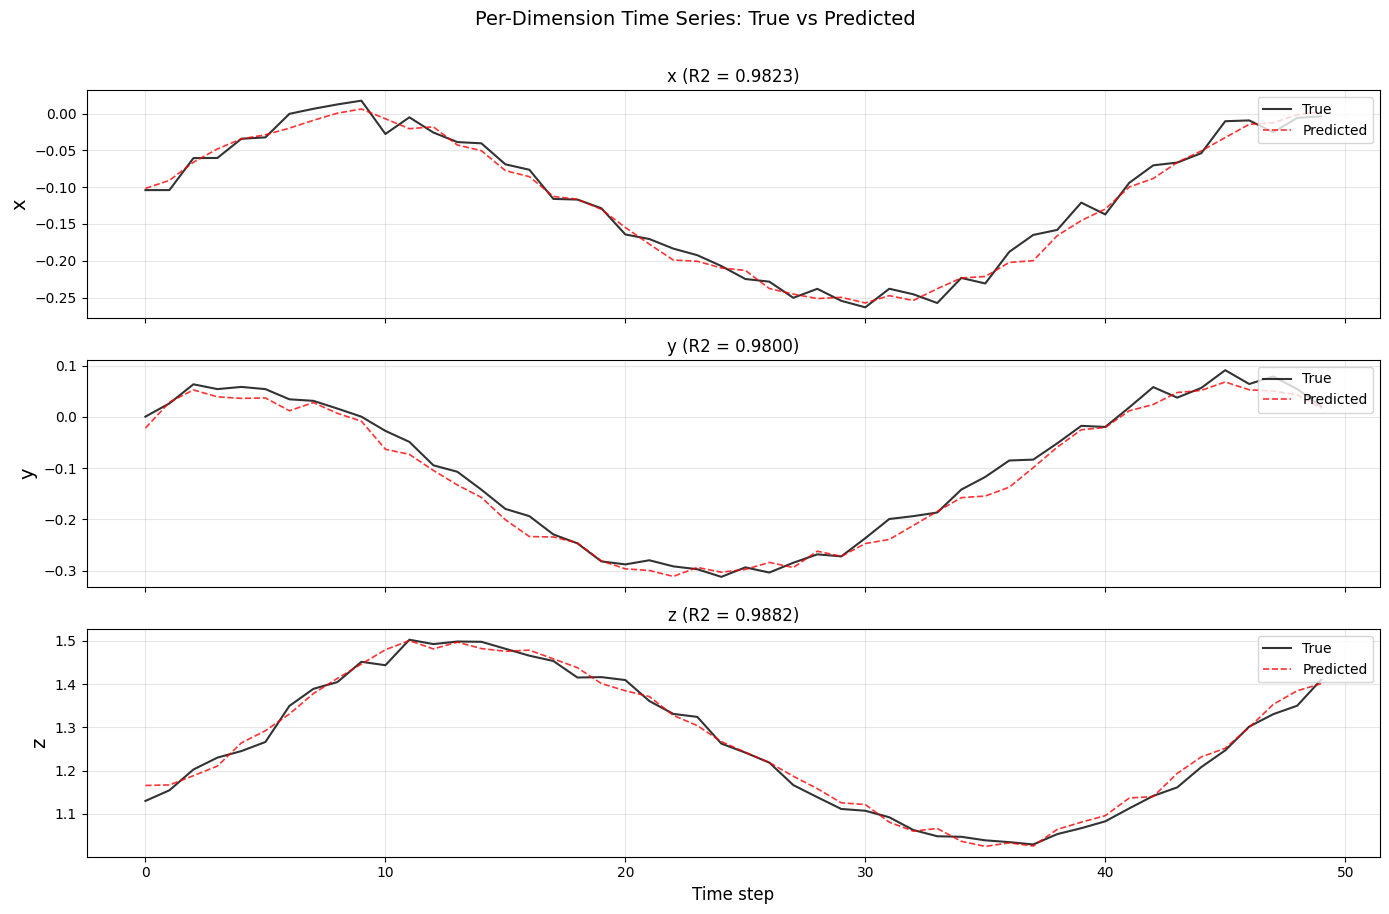

In [ ]:
# ----------------------------------------------------------------
# 6a. Per-dimension time series: predicted vs true (single trajectory)
# ----------------------------------------------------------------
traj_idx = 900  # which test sequence to plot

fig, axes = plt.subplots(N_TARGET_DIMS, 1, figsize=(14, 3 * N_TARGET_DIMS), sharex=True)
if N_TARGET_DIMS == 1:
    axes = [axes]

for d in range(N_TARGET_DIMS):
    ax = axes[d]
    true_vals = target_lorenz[traj_idx, :, d].numpy()
    pred_vals = z_lorenz[traj_idx, :, d].numpy()
    r2_d = r2_score(
        target_lorenz[traj_idx, :, d:d+1],
        z_lorenz[traj_idx, :, d:d+1]
    ).item()
    ax.plot(true_vals, 'k-', lw=1.5, label='True', alpha=0.8)
    ax.plot(pred_vals, 'r--', lw=1.2, label='Predicted', alpha=0.8)
    ax.set_ylabel(f'{dim_labels[d]}', fontsize=14)
    ax.set_title(f'{dim_labels[d]} (R2 = {r2_d:.4f})', fontsize=12)
    ax.legend(loc='upper right', fontsize=10)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel('Time step', fontsize=12)
fig.suptitle('Per-Dimension Time Series: True vs Predicted', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

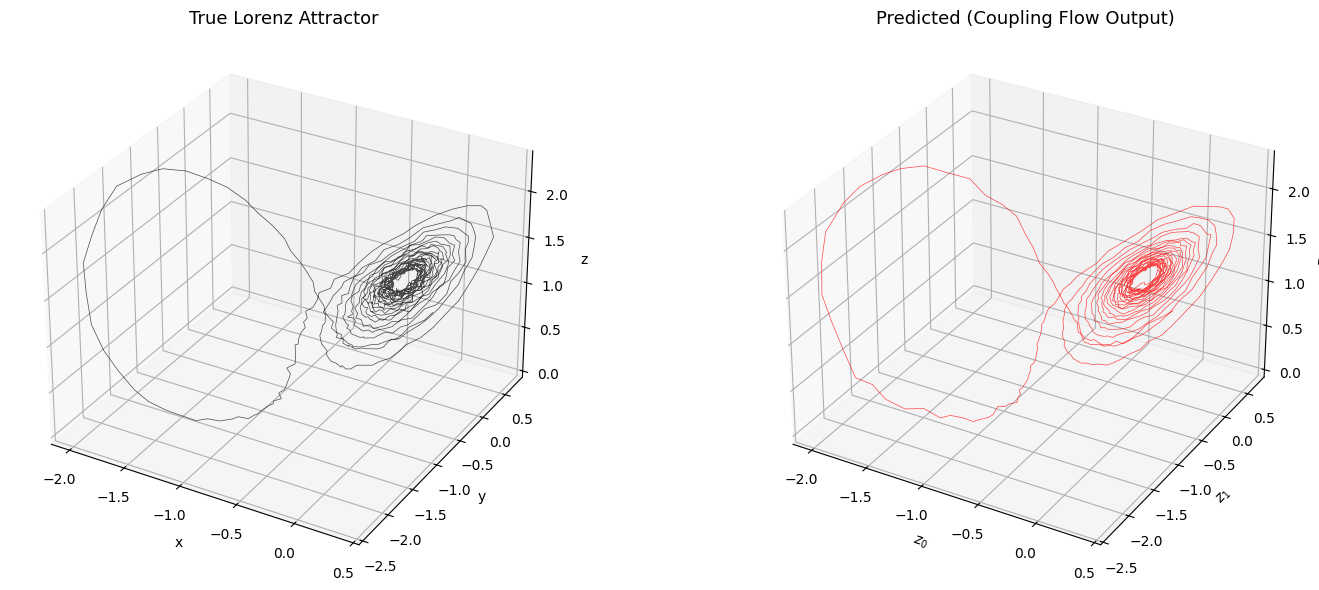

In [ ]:
# ----------------------------------------------------------------
# 6b. 3D Attractor: True vs Predicted
# ----------------------------------------------------------------
# Use a long test trajectory for the attractor plot
# Pick the test trajectory with most timesteps and encode it
test_traj_embedded = trajs['test_trajs'].sequence  # (n_test_traj, T_emb, D)
test_traj_full = trajs['test_trajs_full'].sequence  # (n_test_traj, T_full, 3)
test_full_aligned = test_traj_full[:, offset:, :]   # (n_test_traj, T_emb, 3)

# Encod"e a single long trajectory
traj_to_plot = 1
with torch.no_grad():
    z_traj = encoder(test_traj_embedded[traj_to_plot:traj_to_plot+1].float().to(device)).cpu()

z_lorenz_traj = z_traj[0, :, :N_TARGET_DIMS].numpy()
true_lorenz_traj = test_full_aligned[traj_to_plot].numpy()

fig = plt.figure(figsize=(16, 6))

ax1 = fig.add_subplot(121, projection='3d')
ax1.plot(true_lorenz_traj[:, 0], true_lorenz_traj[:, 1], true_lorenz_traj[:, 2],
         'k-', lw=0.5, alpha=0.7)
ax1.set_title('True Lorenz Attractor', fontsize=13)
ax1.set_xlabel('x'); ax1.set_ylabel('y'); ax1.set_zlabel('z')

ax2 = fig.add_subplot(122, projection='3d')
ax2.plot(z_lorenz_traj[:, 0], z_lorenz_traj[:, 1], z_lorenz_traj[:, 2],
         'r-', lw=0.5, alpha=0.7)
ax2.set_title('Predicted (Coupling Flow Output)', fontsize=13)
ax2.set_xlabel('$z_0$'); ax2.set_ylabel('$z_1$'); ax2.set_zlabel('$z_2$')

plt.tight_layout()
plt.show()

<>:9: SyntaxWarning: invalid escape sequence '\g'
<>:9: SyntaxWarning: invalid escape sequence '\g'
/tmp/ipykernel_2039820/3976358811.py:9: SyntaxWarning: invalid escape sequence '\g'
  ax1.set_xlabel('$z_i$ value (dims $\geq$ 3)', fontsize=12)


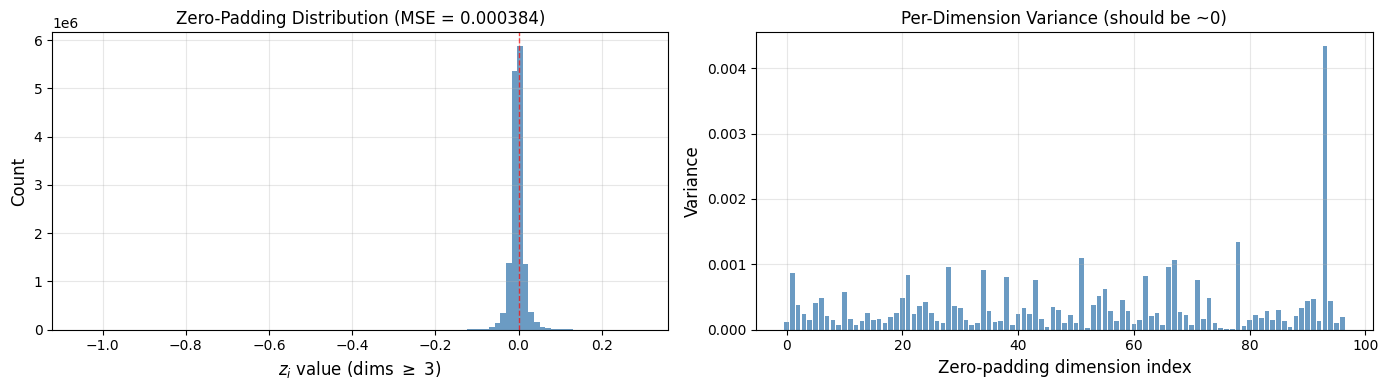

In [ ]:
# ----------------------------------------------------------------
# 6c. Zero-padding accuracy: histogram of |z[..., 3:]|
# ----------------------------------------------------------------
zero_dims = z_zeros.reshape(-1).numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(zero_dims, bins=100, color='steelblue', alpha=0.8, edgecolor='none')
ax1.set_xlabel('$z_i$ value (dims $\geq$ 3)', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title(f'Zero-Padding Distribution (MSE = {zero_mse:.6f})', fontsize=12)
ax1.axvline(0, color='red', ls='--', lw=1, alpha=0.7)
ax1.grid(True, alpha=0.3)

# Per-dim variance of zero-padding dims
n_zero_dims = z_zeros.shape[-1]
dim_vars = z_zeros.reshape(-1, n_zero_dims).var(dim=0).numpy()
ax2.bar(range(n_zero_dims), dim_vars, color='steelblue', alpha=0.8)
ax2.set_xlabel('Zero-padding dimension index', fontsize=12)
ax2.set_ylabel('Variance', fontsize=12)
ax2.set_title('Per-Dimension Variance (should be ~0)', fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

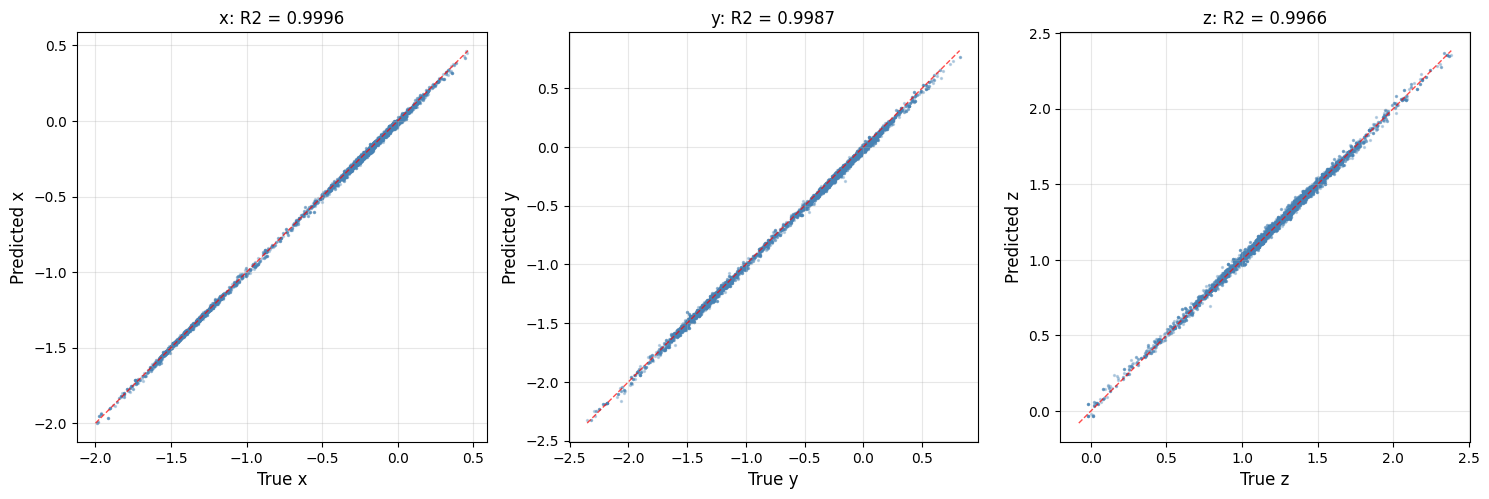

In [ ]:
# ----------------------------------------------------------------
# 6d. Scatter plots: predicted vs true for each Lorenz dimension
# ----------------------------------------------------------------
fig, axes = plt.subplots(1, N_TARGET_DIMS, figsize=(5 * N_TARGET_DIMS, 5))
if N_TARGET_DIMS == 1:
    axes = [axes]

for d in range(N_TARGET_DIMS):
    ax = axes[d]
    true_flat = target_lorenz[..., d].reshape(-1).numpy()
    pred_flat = z_lorenz[..., d].reshape(-1).numpy()
    r2_d = r2_score(
        target_lorenz[..., d].reshape(-1, 1),
        z_lorenz[..., d].reshape(-1, 1)
    ).item()

    # Subsample for readability
    n_pts = min(5000, len(true_flat))
    idx = np.random.choice(len(true_flat), n_pts, replace=False)
    ax.scatter(true_flat[idx], pred_flat[idx], s=2, alpha=0.3, c='steelblue')
    lims = [min(true_flat.min(), pred_flat.min()), max(true_flat.max(), pred_flat.max())]
    ax.plot(lims, lims, 'r--', lw=1, alpha=0.7)
    ax.set_xlabel(f'True {dim_labels[d]}', fontsize=12)
    ax.set_ylabel(f'Predicted {dim_labels[d]}', fontsize=12)
    ax.set_title(f'{dim_labels[d]}: R2 = {r2_d:.4f}', fontsize=12)
    ax.set_aspect('equal', adjustable='box')
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

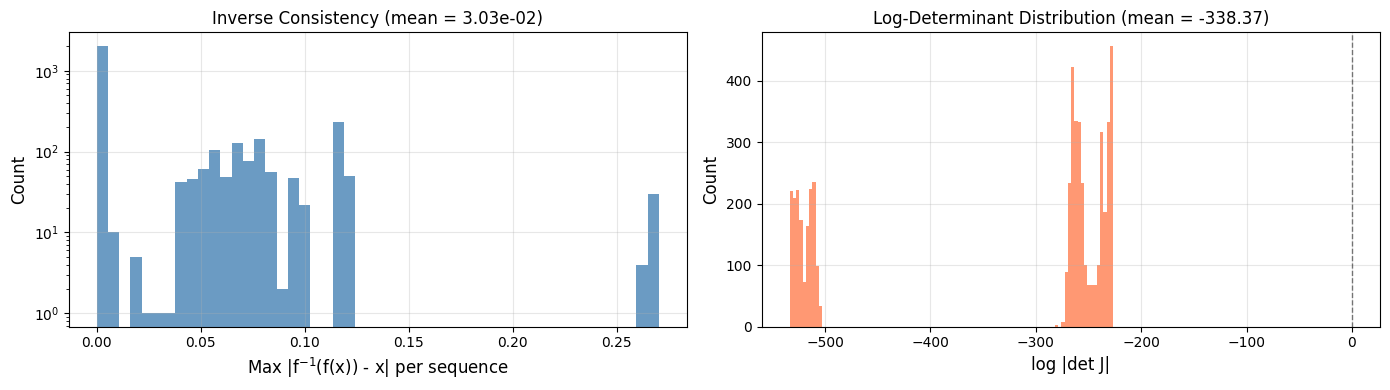

In [ ]:
# ----------------------------------------------------------------
# 6e. Inverse consistency check
# ----------------------------------------------------------------
with torch.no_grad():
    # Pointwise inverse error across all test data
    inv_errors = (x_rec - input_all).abs()
    inv_err_per_sample = inv_errors.reshape(inv_errors.shape[0], -1).max(dim=-1).values.numpy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.hist(inv_err_per_sample, bins=50, color='steelblue', alpha=0.8, edgecolor='none')
ax1.set_xlabel('Max |f$^{-1}$(f(x)) - x| per sequence', fontsize=12)
ax1.set_ylabel('Count', fontsize=12)
ax1.set_title(f'Inverse Consistency (mean = {inv_err_per_sample.mean():.2e})', fontsize=12)
ax1.set_yscale('log')
ax1.grid(True, alpha=0.3)

# Log-det Jacobian distribution (volume change diagnostic)
with torch.no_grad():
    # Compute on a subset for speed
    x_sub = input_all[:min(100, len(input_all))].to(device)
    log_det = encoder.log_det_jacobian(x_sub).cpu()
    log_det_flat = log_det.reshape(-1).numpy()

ax2.hist(log_det_flat, bins=100, color='coral', alpha=0.8, edgecolor='none')
ax2.set_xlabel('log |det J|', fontsize=12)
ax2.set_ylabel('Count', fontsize=12)
ax2.set_title(f'Log-Determinant Distribution (mean = {log_det_flat.mean():.2f})', fontsize=12)
ax2.axvline(0, color='black', ls='--', lw=1, alpha=0.5)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Inverse of [true Lorenz, 97 zeros] vs actual delay embedding:
  MSE: 0.664533
  R2:  -0.8597


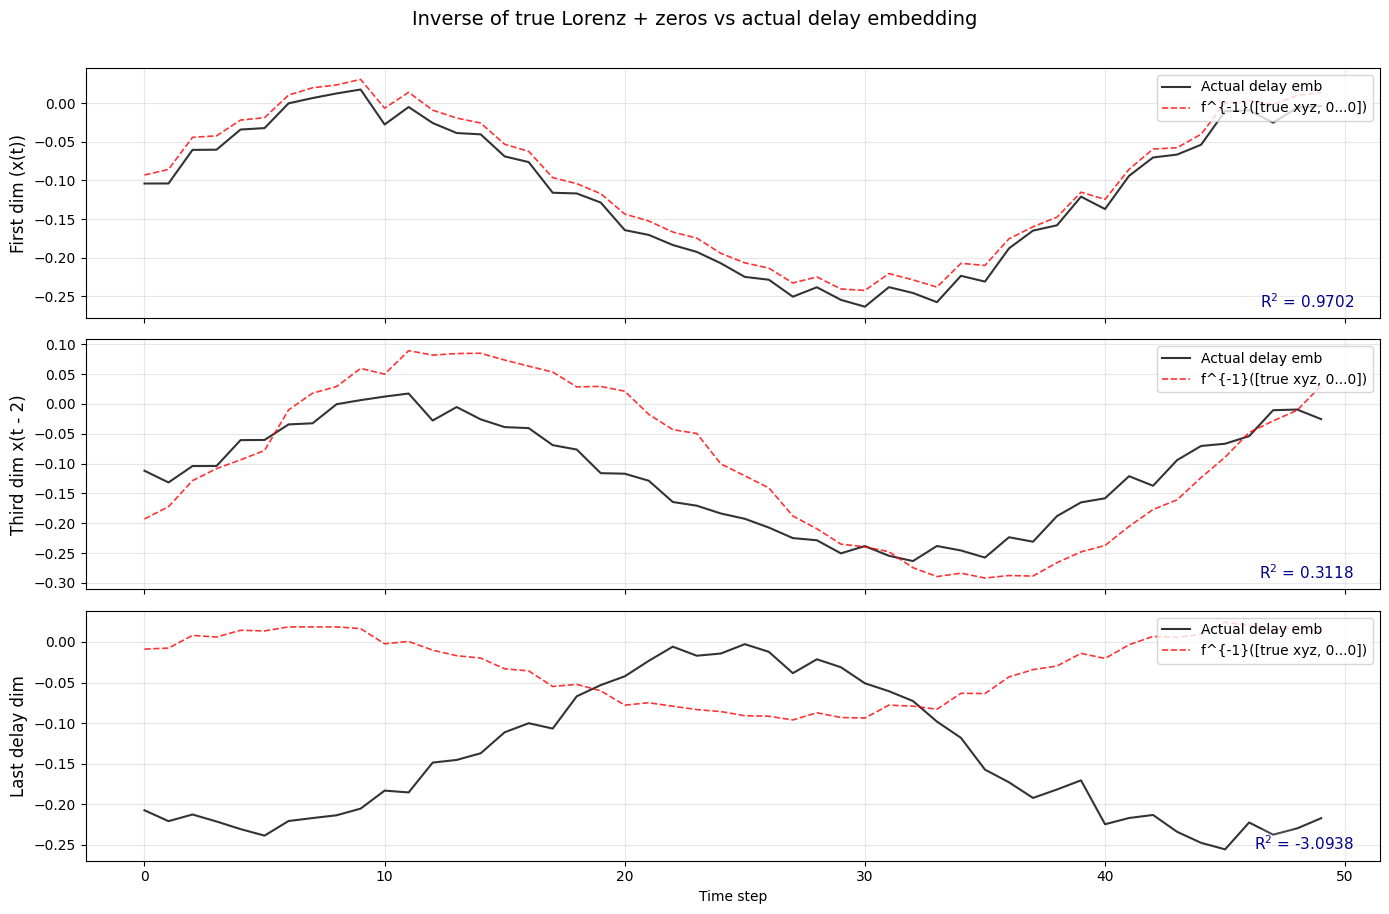

In [ ]:
# ----------------------------------------------------------------
# 6f. Inverse of true Lorenz + zeros: what does f^{-1}([x_true, y_true, z_true, 0,...,0]) look like?
# ----------------------------------------------------------------
# Construct latent = [true Lorenz coords, 97 zeros]
z_padded = torch.zeros_like(z_all)
z_padded[..., :N_TARGET_DIMS] = target_lorenz
# z_padded[..., N_TARGET_DIMS:] = 0 (already zeros)

with torch.no_grad():
    x_from_true = encoder.inverse(z_padded.to(device)).cpu()

# Compare to actual input (delay embedding)
mse_from_true = F.mse_loss(x_from_true, input_all).item()
r2_from_true = r2_score(input_all.reshape(-1, input_all.shape[-1]),
                        x_from_true.reshape(-1, x_from_true.shape[-1])).item()
print("Inverse of [true Lorenz, 97 zeros] vs actual delay embedding:")
print(f"  MSE: {mse_from_true:.6f}")
print(f"  R2:  {r2_from_true:.4f}")

# Compute per-dimension R^2 for the trajectory to plot, for annotation
from numpy import ndarray
traj_idx = 900
per_dim_r2 = []
for d in [0, N_TARGET_DIMS - 1, -1]:  # match dims_to_plot below
    true_vals = input_all[traj_idx, :, d].numpy()
    pred_vals = x_from_true[traj_idx, :, d].numpy()
    # Compute R^2
    ss_res = ((true_vals - pred_vals) ** 2).sum()
    ss_tot = ((true_vals - true_vals.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot != 0 else float('nan')
    per_dim_r2.append(r2)

# Plot: for one trajectory, compare x_from_true to input_all
fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)
dims_to_plot = [0, N_TARGET_DIMS - 1, -1]  # first Lorenz dim, last Lorenz dim, last delay dim
dim_names = ['First dim (x(t))', 'Third dim x(t - 2)', 'Last delay dim']

for i, (d, name) in enumerate(zip(dims_to_plot, dim_names)):
    ax = axes[i]
    ax.plot(input_all[traj_idx, :, d].numpy(), 'k-', lw=1.5, label='Actual delay emb', alpha=0.8)
    ax.plot(x_from_true[traj_idx, :, d].numpy(), 'r--', lw=1.2, label='f^{-1}([true xyz, 0...0])', alpha=0.8)
    ax.set_ylabel(name, fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.3)
    # Annotate R^2 on the plot
    ax.text(0.98, 0.03, f"R$^2$ = {per_dim_r2[i]:.4f}", fontsize=11, color='darkblue',
            ha='right', va='bottom', transform=ax.transAxes, bbox=dict(alpha=0.12, facecolor='w', edgecolor='none'))

axes[-1].set_xlabel('Time step')
fig.suptitle('Inverse of true Lorenz + zeros vs actual delay embedding', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

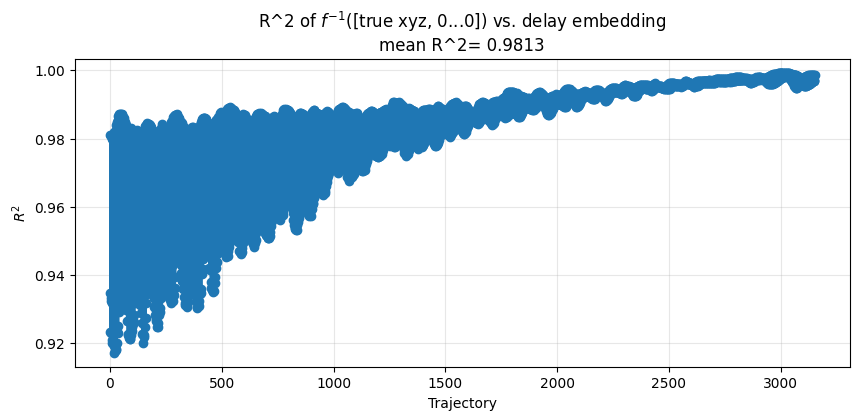

In [ ]:
all_traj_vals = []
for i in range(input_all.shape[0]):
    all_traj_vals.append(r2_score(input_all[i, :, 0], x_from_true[i, :, 0]))
plt.figure(figsize=(10, 4))
plt.plot(all_traj_vals, marker='o')
plt.title("R^2 of $f^{-1}$([true xyz, 0...0]) vs. delay embedding\n"+ f"mean R^2= {np.mean(all_traj_vals):.4f}")
plt.xlabel("Trajectory")
plt.ylabel("$R^2$")
plt.grid(alpha=0.3)

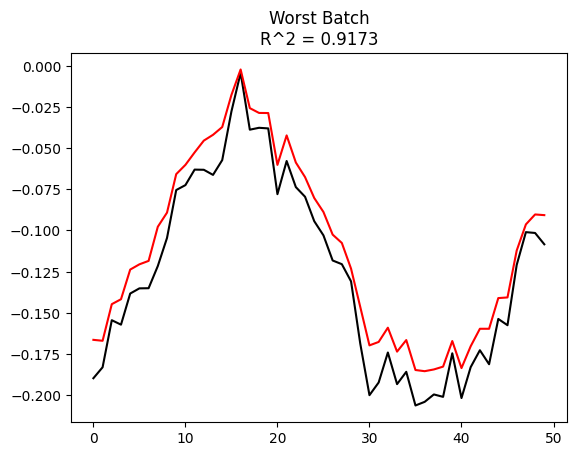

In [ ]:
np.argmin(all_traj_vals)
plt.plot(input_all[np.argmin(all_traj_vals), :, 0], color='k')
plt.plot(x_from_true[np.argmin(all_traj_vals), :, 0], color='r')
r2_val = r2_score(input_all[np.argmin(all_traj_vals), :, 0], x_from_true[np.argmin(all_traj_vals), :, 0])
plt.title(f"Worst Batch\nR^2 = {r2_val:.4f}")
plt.show()

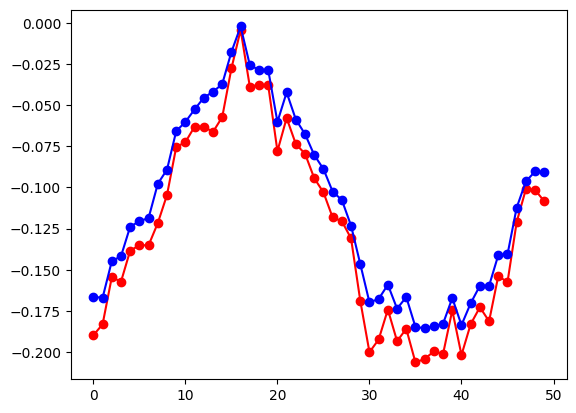

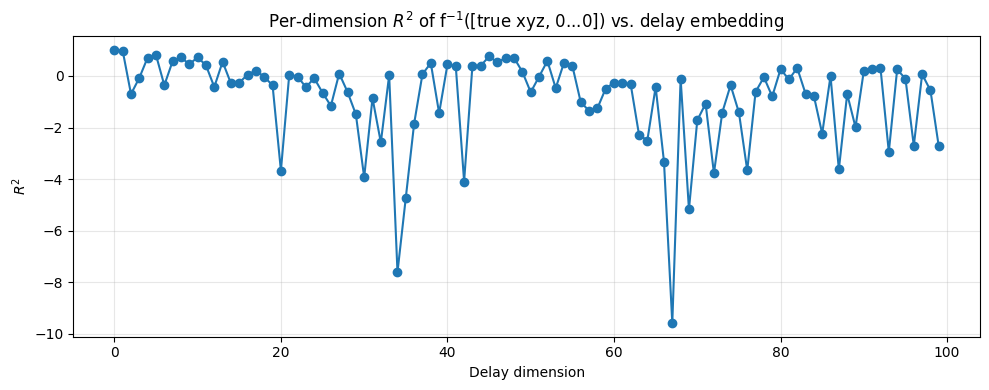

In [ ]:
r2_vals = []
for d in range(input_all.shape[-1]):
    r2_vals.append(r2_score(input_all[:, :, d], x_from_true[:, :, d]))
plt.figure(figsize=(10, 4))
plt.plot(r2_vals, marker='o')
plt.title("Per-dimension $R^2$ of f$^{-1}$([true xyz, 0...0]) vs. delay embedding")
plt.xlabel("Delay dimension")
plt.ylabel("$R^2$")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [ ]:
import subprocess
from datetime import datetime

now_str = datetime.now().strftime("%Y-%m-%d %H-%M-%S")
output_file = f"reports/{now_str} - Coupling Flow (Lorenz - test frame) N_DELAYS={N_DELAYS} N_TARGET_DIMS={N_TARGET_DIMS} DELAY_SPACING={DELAY_SPACING} COUPLING_TYPE={COUPLING_TYPE}"
cmd = f"uv run jupyter nbconvert --to html --output '{output_file}' '/home/eisenaj/code/JacobianODE/_jupyter/Coupling Flow (Lorenz - test frame).ipynb'"
# Uncomment to export:
subprocess.run(cmd, shell=True)
# print(f"Export command:\n{cmd}")

[NbConvertApp] Converting notebook /home/eisenaj/code/JacobianODE/_jupyter/Coupling Flow (Lorenz - test frame).ipynb to html
[NbConvertApp] ERROR | Notebook JSON is invalid: Additional properties are not allowed ('id' was unexpected)

Failed validating 'additionalProperties' in markdown_cell:

On instance['cells'][0]:
{'cell_type': 'markdown',
 'id': '263c5baf',
 'metadata': {},
 'source': '# Coupling Flow (Lorenz) — Test Frame\n'
           '\n'
           'Train an **affine couplin...'}
[NbConvertApp] WARNING | Alternative text is missing on 8 image(s).
[NbConvertApp] Writing 1430810 bytes to /home/eisenaj/code/JacobianODE/_jupyter/reports/2026-03-25 00-51-22 - Coupling Flow (Lorenz - test frame) N_DELAYS=100 N_TARGET_DIMS=3 DELAY_SPACING=1 COUPLING_TYPE=spline.html


CompletedProcess(args="uv run jupyter nbconvert --to html --output 'reports/2026-03-25 00-51-22 - Coupling Flow (Lorenz - test frame) N_DELAYS=100 N_TARGET_DIMS=3 DELAY_SPACING=1 COUPLING_TYPE=spline' '/home/eisenaj/code/JacobianODE/_jupyter/Coupling Flow (Lorenz - test frame).ipynb'", returncode=0)

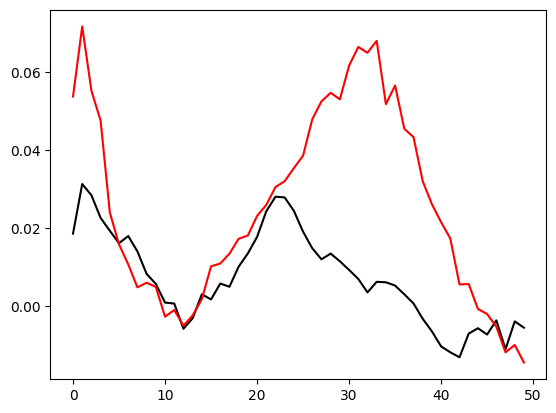

In [ ]:
plt.plot(z_null[0, :, 0], color='k')
plt.plot(z_null[0, :, 1], color='r')
plt.show()


In [ ]:
z_null = z_all[..., N_TARGET_DIMS:]
print(f"Null dim std:  {z_null.std().item():.4f}")
print(f"Null dim |max|: {z_null.abs().max().item():.4f}")

Null dim std:  0.0194
Null dim |max|: 1.0540
